## Manual Backpropogation

In [1]:
import math
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd
%matplotlib inline

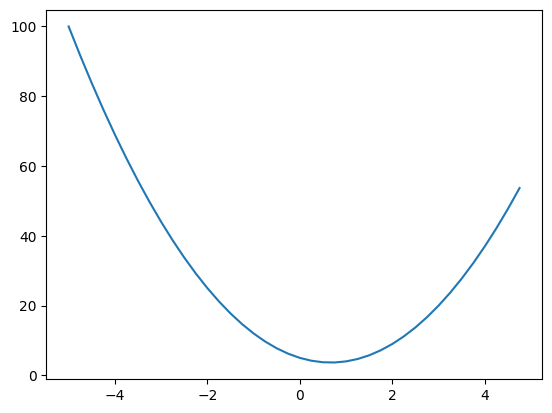

In [2]:
def f(x):
    return 3*x**2 - 4*x + 5

xs =  np.arange(-5,5,0.25)
ys = f(xs)
plt.plot(xs,ys)


In [3]:
h = 0.001
x = 2/3

(f(x+h) - f(x))/h

0.0029999999995311555

In [4]:
a = 3 
b = -2
c = 10

d1 = a*b + c
b += h
d2 = a*b + c

print(f'{d1 , d2} ,  slope : {(d2-d1) / h}')

(4, 4.003) ,  slope : 3.0000000000001137


In [5]:
class Value:

    '''def __init__(self, data, _children = () , _op = '', label = ''):
        self.data = data


        self._prev = set(_children)
        self._op = _op
        self.label = label
'''


    
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        # --- MISSING LINE BELOW? ---
        self.grad = 0.0 
        self._backward = lambda: None

        # ---------------------------
        self._prev = set(_children)
        self._op = _op
        self.label = label



    def __repr__(self):
        return f"Value(data={self.data})"
    
    def __add__(self, other):

        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad = 1 * out .grad
            other.grad = 1 * out.grad
        out._backward = _backward

        return out
    

    def __radd__(self, other):
        return self + other

    def __neg__(self): # -self
        return self * -1

    def __sub__(self, other): # self - other
        return self + (-other)

    
    def __mul__(self, other):

        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other) , '*')

        def _backward():
            self.grad = other.data * out .grad
            other.grad = self.data * out.grad
        out._backward = _backward

        return out
    
    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data**other, (self,), f'**{other}')

        def _backward():
            self.grad += other * self.data **(other - 1)   # exercise :)
        out._backward = _backward

        return out

    def __truediv__(self, other):
        return self * other**-1

    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')
        
        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward
        
        return out


    def __rmul__(self, other):
        return self * other
    
    def tanh(self):
        x    =  self.data
        t = (math.exp(2*x) -1) / (math.exp(2*x) +1) 
        out = Value(t, (self, ), 'tanh')

        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward

        return out


    def backward(self):

        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)

        build_topo(self)

        self.grad = 1

        for node in reversed(topo):
            node._backward()



a = Value(3)
b = Value(-2)
c = Value(10)

#print(a*b + c)

d = ((a).__mul__(b)).__add__(c)
    
a = Value(3, label='a') 
b = Value(-2, label= 'b') 
c = Value(10, label= 'c') 
e = a*b ; e.label= 'e'
d = c + e; d.label= 'd'
f = Value(-2 ,  label='f')
L = d*f ; L.label='L'

In [6]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
    
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name = uid + n._op, label = n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)
            
    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
        
    return dot


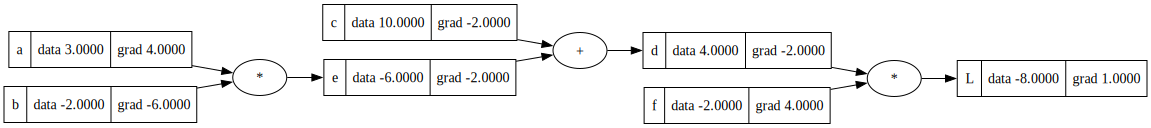

In [7]:
L.grad = 1.00
d.grad = -2.00
f.grad = 4.00
c.grad = -2
e.grad = -2

b.grad = -2 * 3
a.grad = -2 * -2

draw_dot(L)



In [8]:
a.data += 0.0001 * a.grad 
b.data += 0.0001 * b.grad 
d.data += 0.0001 * d.grad 
f.data += 0.0001 * f.grad 

e = a * b
d = e + f
L = d * f
print(L.data)


16.001199599904


In [9]:
def lol():
    
    
    
    h = 0.001

    a = Value(3, label='a') 
    b = Value(-2, label= 'b') 
    c = Value(10, label= 'c') 
    e = a*b ; e.label= 'e'
    d = c + e; d.label= 'd'
    f = Value(-2, label='f')
    L = d*f ; L.label='L'
    L1 = L.data

    a = Value(3, label='a')
    a.data =+ h 
    b = Value(-2, label= 'b') 
    c = Value(10, label= 'c') 
    e = a*b ; e.label= 'e'
    d = c + e; d.label= 'd'
    f = Value(-2,  label='f')
    L = d*f ; L.label='L'
    L2 = L.data 


    print((L2 - L1 )/ h)

lol()

-11995.999999999998


## Backpropogation through a Neuron


In [10]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
b = Value(6.88137, label='b')
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

o.backward()   # Through the use of TOPOLOGICAL SORTING 

In [11]:
'''o.grad = 1

#do/dn = 1 - tanh(x)**2
n.grad = 1 - o.data**2

b.grad = 0.5
x1w1x2w2.grad = 0.5

x2w2.grad = 0.5
x1w1.grad = 0.5


w2.grad = 0
x2.grad = 0.5

w1.grad = 1
x1.grad = -1.5 

o.grad = 1
o._backward()  
n._backward()
x1w1x2w2._backward()
x1w1._backward()
x2w2._backward()'''

'o.grad = 1\n\n#do/dn = 1 - tanh(x)**2\nn.grad = 1 - o.data**2\n\nb.grad = 0.5\nx1w1x2w2.grad = 0.5\n\nx2w2.grad = 0.5\nx1w1.grad = 0.5\n\n\nw2.grad = 0\nx2.grad = 0.5\n\nw1.grad = 1\nx1.grad = -1.5 \n\no.grad = 1\no._backward()  \nn._backward()\nx1w1x2w2._backward()\nx1w1._backward()\nx2w2._backward()'

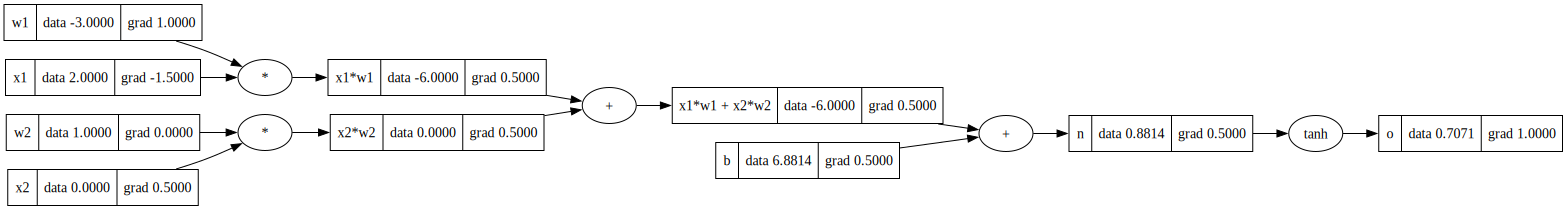

In [12]:
draw_dot(o)

In [13]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
b = Value(6.88137, label='b')
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
#-----------
e = (2*n).exp()  ; o.label = 'o'
o = (e - 1) / (e + 1)

o.backward()   # Through the use of TOPOLOGICAL SORTING 

## Neural Networks


In [14]:
import random

class Neuron:

    def __init__(self, nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))

    def __call__(self, x):
        # w * x + b
        act = sum((wi*xi for wi, xi in zip(self.w, x)) , self.b) 
        out = act.tanh()
        return out

    def parameters(self):
        return self.w + [self.b]
 
 
class Layer:

    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else  outs

    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]

class MLP:

    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x
    def parameters(self):
        return [p for layers in self.layers for p in layers.parameters()]




In [15]:
x = [2.0, 3.0 , -1 ]
n = MLP(3, [4,4,1])
n(x)


Value(data=-0.2858693676758287)

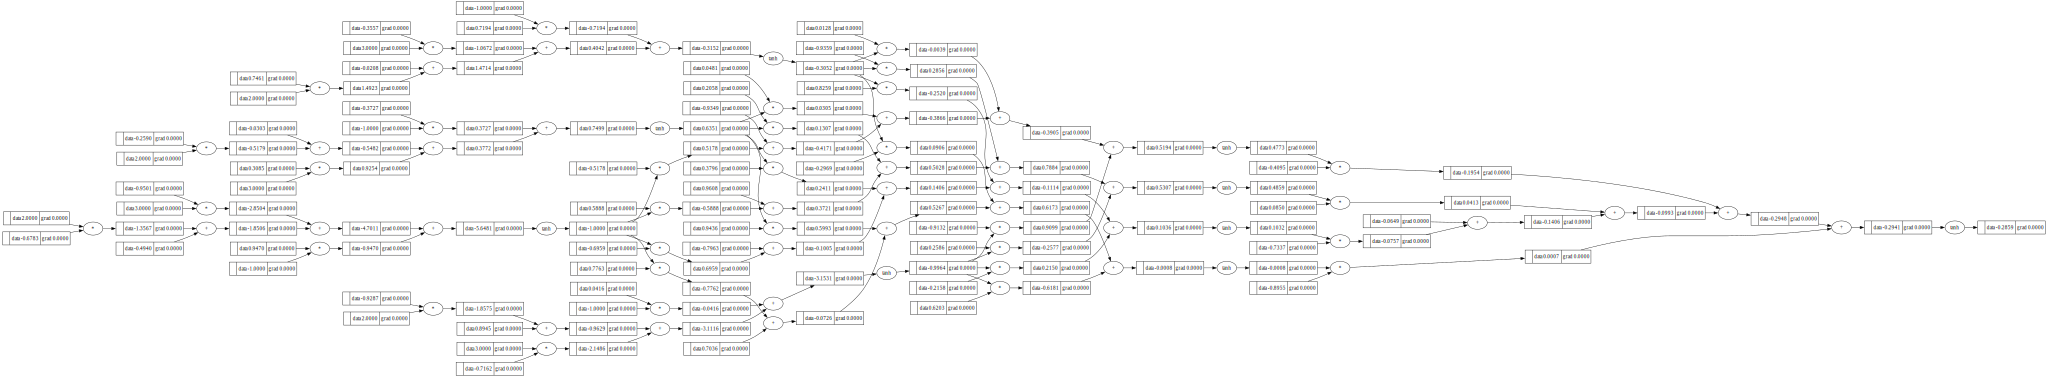

In [16]:
draw_dot(n(x))

In [17]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets


In [18]:
   
for k in range(200):

    #forward pass
    ypred = [n(x) for x in xs]
    loss = sum([(yout - ygt)**2 for ygt, yout in zip(ys, ypred)])

    # zero grad 
    for p in n.parameters():
        p.grad = 0

    #backward pass
    loss.backward()

    #update process
    for p in n.parameters():
        p.data += -0.05 * p.grad

    print(k, loss.data)

0 5.955491671067731
1 5.167433854707111
2 3.7297872614471093
3 3.569191120832687
4 3.6749990631979736
5 3.859767401751701
6 3.941417359942132
7 4.018016744982496
8 4.080270857025375
9 2.4773317221478037
10 2.577862527534505
11 2.6751395514714416
12 2.7554202799322023
13 1.4246471594893104
14 1.431733930199477
15 1.4750162503706608
16 1.5263917940487777
17 1.5834728189499432
18 1.6299814513282127
19 1.6702829285324607
20 1.7110166188007139
21 0.898055358708349
22 0.90548749809379
23 0.9241531583519839
24 0.9449804118715138
25 0.7193849145202931
26 0.722383454284708
27 0.7340658234492772
28 0.7466446047146481
29 0.4990751924379846
30 0.49966224191039493
31 0.5059144838886336
32 0.41789256968763383
33 0.41981959047904316
34 0.3754039093815234
35 0.3709187893946019
36 0.37167589822091646
37 0.3750153569708413
38 0.33570957044411825
39 0.3352012203674138
40 0.33690297253240564
41 0.34001271252326287
42 0.34295837768840387
43 0.2765021164375017
44 0.27827030662076496
45 0.28118636156228133
4

In [19]:
ypred

[Value(data=0.9641481348613113),
 Value(data=-0.8715904144448864),
 Value(data=-0.8531704424799067),
 Value(data=0.950447479203787)]